# Delta策略单日持仓生成与回测案例展示

本notebook展示如何使用delta模块进行单日持仓生成和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 1. 设置策略参数

In [4]:
# 设置标的和日期
instrument_id = '518880'
trade_ymd = '20260319'

# 策略参数配置
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_demo',
    'stride': 1,

    'short_window': 60,      # 短期窗口
    'long_window': 300,      # 长期窗口
    'y_window': 300,         # 标签窗口

    'open_threshold': 2,     # 开仓阈值
    'open_confidence': 0,    # 开仓置信度
    'close_confidence': 0.2, # 平仓置信度
    'standard_num': 1000,    # 标准数量

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 2. 训练模型（可选）

In [19]:
trade_dates = get_trade_dates()
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260302",    # 训练集结束日期
    valid_start="20260303",  # 验证集开始日期
    valid_end="20260304",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
model = train_model(X_train, y_train, X_valid, y_valid, param_dict)
model_path = f"/home/jovyan/work/model/delta_v1.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260304 (2天)
测试集: 20251201 ~ 20251231 (23天)
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
20260303: 产生 794 个样本
20260304: 产生 886 个样本
20251201: 产生 805 个样本
20251202: 产生 794 个样本
20251203: 产生 791 个样本
20251204: 产生 778 个样本
20251205: 产生 813 个样本
20251208: 产生 803 个样本
20251

## 3. 加载预训练模型（推荐）

In [5]:
# 加载预训练模型
model_path = f"/home/jovyan/work/model/delta_v1.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_v1.pkl


## 4. 创建策略实例

In [6]:
# 创建策略实例
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")
print(f"策略参数: {param_dict}")

策略已创建: delta_v1_demo
策略参数: {'instrument_id': '518880', 'trade_ymd': '20260319', 'name': 'delta_v1_demo', 'stride': 1, 'short_window': 60, 'long_window': 300, 'y_window': 300, 'open_threshold': 2, 'open_confidence': 0, 'close_confidence': 0.2, 'standard_num': 1000, 'k_pct': 1, 'k_up': 3, 'k_down': 3, 'x_window': 300}


## 5. 单日持仓生成

In [7]:
# 加载当日数据
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)
print(f"加载 {trade_ymd} 数据，共 {len(snap_list)} 个snapshot")

# 生成持仓信号
position_dict = {}
for snap in snap_list:
    strategy.on_snap(snap)
    position_dict[snap['time_mark']] = strategy.position_last


加载 20260319 数据，共 14402 个snapshot


## 6. 单日回测

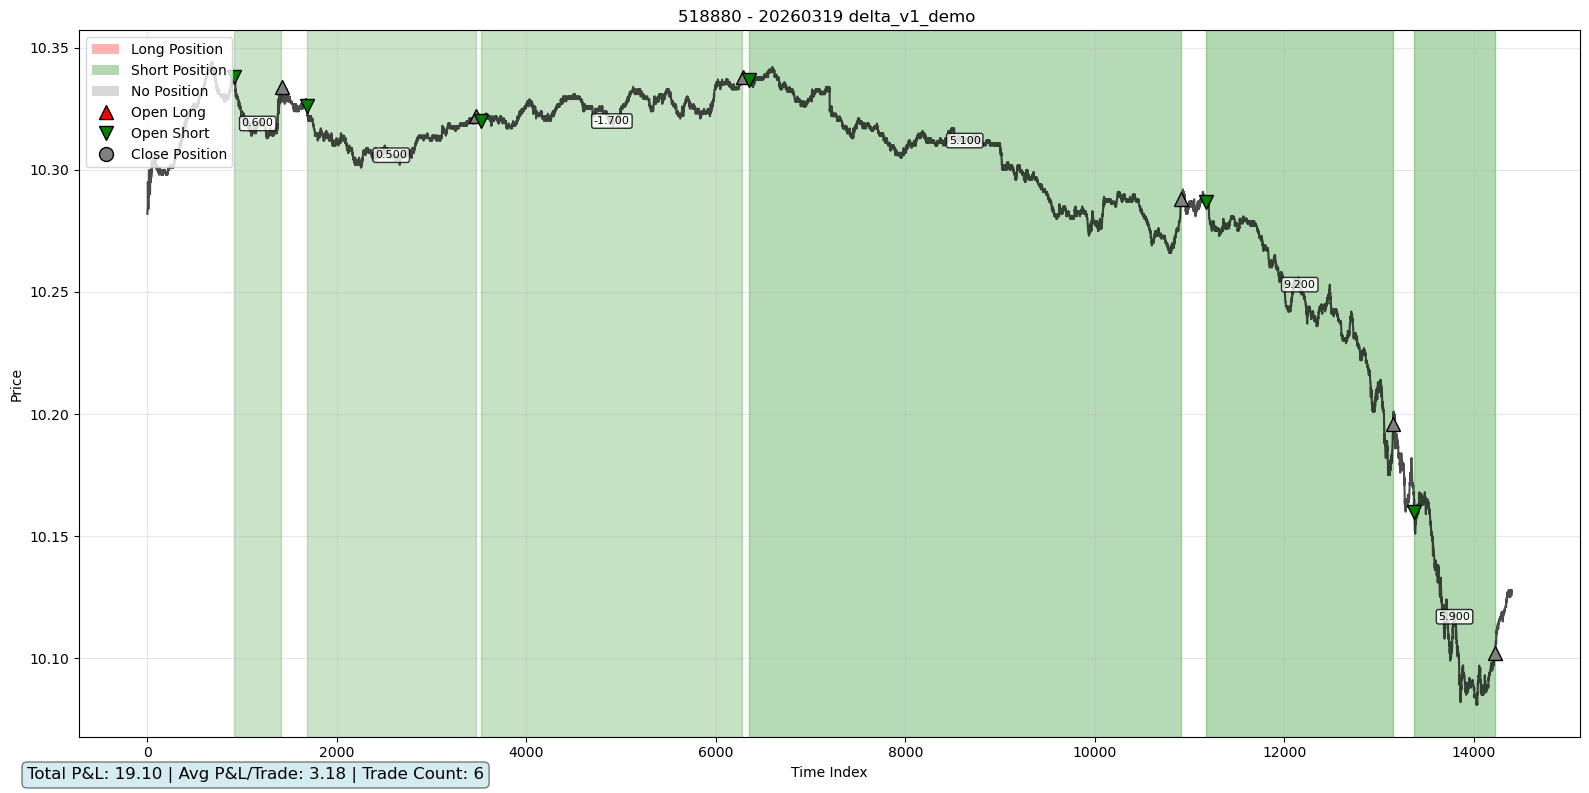

In [8]:
# 执行单日回测
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')

from single_day_backtest import single_day_backtest

profit_df = single_day_backtest(
    instrument_id=instrument_id,
    trade_ymd=trade_ymd,
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official= False, 
)

## 7. 多日回测（批量处理）